# Сборный проект-5

Вам поручено разработать демонстрационную версию поиска изображений по запросу.

Для демонстрационной версии нужно обучить модель, которая получит векторное представление изображения, векторное представление текста, а на выходе выдаст число от 0 до 1 — покажет, насколько текст и картинка подходят друг другу.

## Описание данных


Данные доступны по [ссылке](https://code.s3.yandex.net/datasets/dsplus_integrated_project_4.zip).

В файле `train_dataset.csv` находится информация, необходимая для обучения: имя файла изображения, идентификатор описания и текст описания. Для одной картинки может быть доступно до 5 описаний. Идентификатор описания имеет формат `<имя файла изображения>#<порядковый номер описания>`.

В папке `train_images` содержатся изображения для тренировки модели.

В файле `CrowdAnnotations.tsv` — данные по соответствию изображения и описания, полученные с помощью краудсорсинга. Номера колонок и соответствующий тип данных:

1. Имя файла изображения.
2. Идентификатор описания.
3. Доля людей, подтвердивших, что описание соответствует изображению.
4. Количество человек, подтвердивших, что описание соответствует изображению.
5. Количество человек, подтвердивших, что описание не соответствует изображению.

В файле `ExpertAnnotations.tsv` содержатся данные по соответствию изображения и описания, полученные в результате опроса экспертов. Номера колонок и соответствующий тип данных:

1. Имя файла изображения.
2. Идентификатор описания.

3, 4, 5 — оценки трёх экспертов.

Эксперты ставят оценки по шкале от 1 до 4, где 1 — изображение и запрос совершенно не соответствуют друг другу, 2 — запрос содержит элементы описания изображения, но в целом запрос тексту не соответствует, 3 — запрос и текст соответствуют с точностью до некоторых деталей, 4 — запрос и текст соответствуют полностью.

В файле `test_queries.csv` находится информация, необходимая для тестирования: идентификатор запроса, текст запроса и релевантное изображение. Для одной картинки может быть доступно до 5 описаний. Идентификатор описания имеет формат `<имя файла изображения>#<порядковый номер описания>`.

В папке `test_images` содержатся изображения для тестирования модели.

### Подключение необходимых библиотек, настройка окружения

In [100]:
!pip install -U ipywidgets jupyter -q

In [101]:
!pip install wordcloud -q
!pip install catboost -q
!pip install scikit-learn -q
!pip install nltk -q

In [102]:
!pip install spacy -q

In [103]:
!pip install keras_nlp -q

In [104]:
!pip install tensorflow -q

In [105]:
!pip install torchvision -q

In [106]:
!pip install transformers -q

In [107]:
import re
import nltk
import spacy
import keras_nlp
import matplotlib
import numpy as np
import pandas as pd
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer



from tqdm.notebook import tqdm
tqdm.pandas()

from wordcloud import WordCloud
from nltk.corpus import stopwords as nltk_stopwords

import tensorflow as tf
from tensorflow.keras.layers import (Dense, GlobalAveragePooling2D, Flatten, Dropout, BatchNormalization)
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow import keras

import torchvision.models as models
import torch
import torch.nn as nn
from tensorflow.keras.callbacks import EarlyStopping

import random
from transformers import BertTokenizer, BertModel


from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import GroupShuffleSplit, GridSearchCV, cross_val_score, KFold, RandomizedSearchCV
from catboost import CatBoostRegressor

In [108]:
nltk.download('stopwords')
stopwords = set(nltk_stopwords.words('english'))

[nltk_data] Error loading stopwords: Security Violation
[nltk_data]     [pathsec.urlopen]: refusing a proxied fetch of
[nltk_data]     'https://raw.githubusercontent.com/nltk/nltk_data/gh-
[nltk_data]     pages/index.xml'. A configured proxy performs the
[nltk_data]     egress, so NLTK cannot pin the validated IP and SSRF
[nltk_data]     protection cannot be enforced (CWE-918). If and only
[nltk_data]     if the proxy is trusted to be SSRF-safe, opt in via
[nltk_data]     NLTK_ALLOW_PROXIED_URLOPEN=1 or
[nltk_data]     nltk.pathsec.ALLOW_PROXIED_FETCH=True.


In [109]:
RANDOM_STATE = 42
SEED = 42

### Загрузка данных

In [110]:
train_dataset = pd.read_csv('data/train_dataset.csv', sep = ',')

In [111]:
train_dataset.head(2)

,image,query_id,query_text
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...
1,1262583859_653f1469a9.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...


In [112]:
crowd_dataset = pd.read_csv('data/CrowdAnnotations.tsv', sep = '\t')

In [113]:
crowd_dataset.head(2)

,1056338697_4f7d7ce270.jpg,1056338697_4f7d7ce270.jpg#2,1,3,0
0,1056338697_4f7d7ce270.jpg,114051287_dd85625a04.jpg#2,0.0,0,3
1,1056338697_4f7d7ce270.jpg,1427391496_ea512cbe7f.jpg#2,0.0,0,3


In [114]:
crowd_dataset = crowd_dataset.rename(columns={'1056338697_4f7d7ce270.jpg': 'image'})
crowd_dataset = crowd_dataset.rename(columns={'1056338697_4f7d7ce270.jpg#2': 'query_id'})
crowd_dataset = crowd_dataset.rename(columns={'1': 'confirm_ratio'})
crowd_dataset = crowd_dataset.rename(columns={'3': 'confirm_number'})
crowd_dataset = crowd_dataset.rename(columns={'0': 'unconfirm_number'})

In [115]:
expert_dataset = pd.read_csv('data/ExpertAnnotations.tsv', sep = '\t')

In [116]:
expert_dataset.head(2)

,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,1,1.1,1.2
0,1056338697_4f7d7ce270.jpg,2718495608_d8533e3ac5.jpg#2,1,1,2
1,1056338697_4f7d7ce270.jpg,3181701312_70a379ab6e.jpg#2,1,1,2


In [117]:
expert_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 5821 entries, 0 to 5820
Data columns (total 5 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   1056338697_4f7d7ce270.jpg    5821 non-null   str  
 1   2549968784_39bfbe44f9.jpg#2  5821 non-null   str  
 2   1                            5821 non-null   int64
 3   1.1                          5821 non-null   int64
 4   1.2                          5821 non-null   int64
dtypes: int64(3), str(2)
memory usage: 227.5 KB


In [118]:
expert_dataset = expert_dataset.rename(columns={'1056338697_4f7d7ce270.jpg': 'image'})
expert_dataset = expert_dataset.rename(columns={'2549968784_39bfbe44f9.jpg#2': 'query_id'})
expert_dataset = expert_dataset.rename(columns={'1': 'first_expert'})
expert_dataset = expert_dataset.rename(columns={'1.1': 'second_expert'})
expert_dataset = expert_dataset.rename(columns={'1.2': 'third_expert'})

In [119]:
queries_dataset = pd.read_csv('data/test_queries.csv', sep = '|', index_col = 0)

In [120]:
queries_dataset.head(2)

,query_id,query_text,image
0,1177994172_10d143cb8d.jpg#0,"Two blonde boys , one in a camouflage shirt an...",1177994172_10d143cb8d.jpg
1,1177994172_10d143cb8d.jpg#1,Two boys are squirting water guns at each other .,1177994172_10d143cb8d.jpg


In [121]:
test_images = pd.read_csv('data/test_images.csv')

In [122]:
test_images.head(2)

,image
0,3356748019_2251399314.jpg
1,2887171449_f54a2b9f39.jpg


In [123]:
test_images.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   image   100 non-null    str  
dtypes: str(1)
memory usage: 928.0 bytes


In [124]:
data_collection = [train_dataset, expert_dataset, queries_dataset, test_images]

In [125]:
for i in data_collection:
    print(i.head(0))
    print('Кол-во дубликатов:', i.duplicated().sum(), 'Кол-во пропусков:', i.isnull().sum().sum())
    print()

Empty DataFrame
Columns: [image, query_id, query_text]
Index: []
Кол-во дубликатов: 0 Кол-во пропусков: 0

Empty DataFrame
Columns: [image, query_id, first_expert, second_expert, third_expert]
Index: []
Кол-во дубликатов: 0 Кол-во пропусков: 0

Empty DataFrame
Columns: [query_id, query_text, image]
Index: []
Кол-во дубликатов: 0 Кол-во пропусков: 0

Empty DataFrame
Columns: [image]
Index: []
Кол-во дубликатов: 0 Кол-во пропусков: 0



In [126]:
del data_collection

Возьмем случайную выборку из тренировочного датасета и тестового датасета:

In [127]:
train_image = list(train_dataset['image'].sample(n=7))
test_image = list(test_images['image'].sample(n=7))

In [128]:
train_image

['363617160_6cb0c723be.jpg',
 '491405109_798222cfd0.jpg',
 '3578841731_f775cab089.jpg',
 '2526585002_10987a63f3.jpg',
 '3564543247_05cdbc31cf.jpg',
 '1084040636_97d9633581.jpg',
 '2944952557_8484f0da8f.jpg']

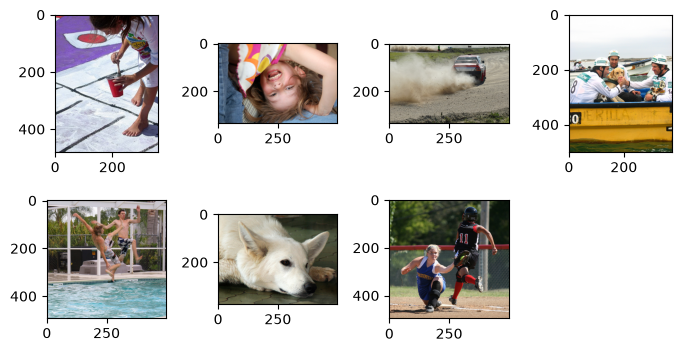

In [129]:
fig = plt.figure(figsize=(7, 7))

for i in range(len(train_image)):
    fig.add_subplot(4, 4, i+1)
    image = Image.open(Path('data/train_images', train_image[i]))
    plt.imshow(image)
    plt.tight_layout()

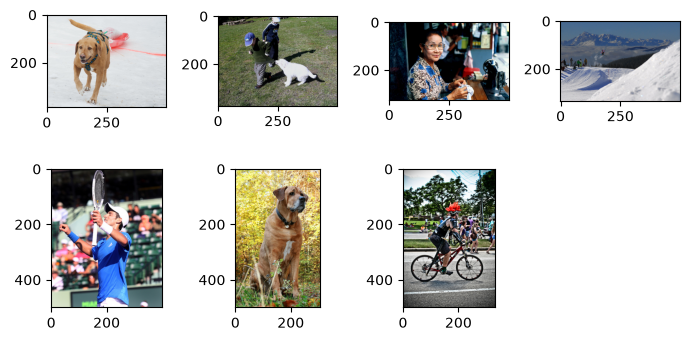

In [130]:
fig = plt.figure(figsize=(7, 7))

for i in range(len(train_image)):
    fig.add_subplot(4, 4, i+1)
    image = Image.open(Path('data/test_images', test_image[i]))
    plt.imshow(image)
    plt.tight_layout()

### Промежуточные итоги

- Настроили заранее окружение, установим и импортировав необходимые библиотеки;
- Загрузили необходимые данные, посмотрели на них, изменили названия полей;
- Типы полей соответствуют по их назначению;
- Пропусков в данных нет;
- Дубликотов в данных нет;
- В тренировочной и тестовой выборке встречаются изображения с детьми, что противоречит правилам в нашем проекте;
- Изображения встречаются с разным соотношением сторон.

## Исследовательский анализ данных

Наш датасет содержит экспертные и краудсорсинговые оценки соответствия текста и изображения.

В файле с экспертными мнениями для каждой пары изображение-текст имеются оценки от трёх специалистов. Для решения задачи вы должны эти оценки агрегировать — превратить в одну. Существует несколько способов агрегации оценок, самый простой — голосование большинства: за какую оценку проголосовала большая часть экспертов (в нашем случае 2 или 3), та оценка и ставится как итоговая. Поскольку число экспертов меньше числа классов, может случиться, что каждый эксперт поставит разные оценки, например: 1, 4, 2. В таком случае данную пару изображение-текст можно исключить из датасета.

Вы можете воспользоваться другим методом агрегации оценок или придумать свой.

В файле с краудсорсинговыми оценками информация расположена в таком порядке:

1. Доля исполнителей, подтвердивших, что текст **соответствует** картинке.
2. Количество исполнителей, подтвердивших, что текст **соответствует** картинке.
3. Количество исполнителей, подтвердивших, что текст **не соответствует** картинке.

После анализа экспертных и краудсорсинговых оценок выберите либо одну из них, либо объедините их в одну по какому-то критерию: например, оценка эксперта принимается с коэффициентом 0.6, а крауда — с коэффициентом 0.4.

Ваша модель должна возвращать на выходе вероятность соответствия изображения тексту, поэтому целевая переменная должна иметь значения от 0 до 1.


### Экспертные оценки

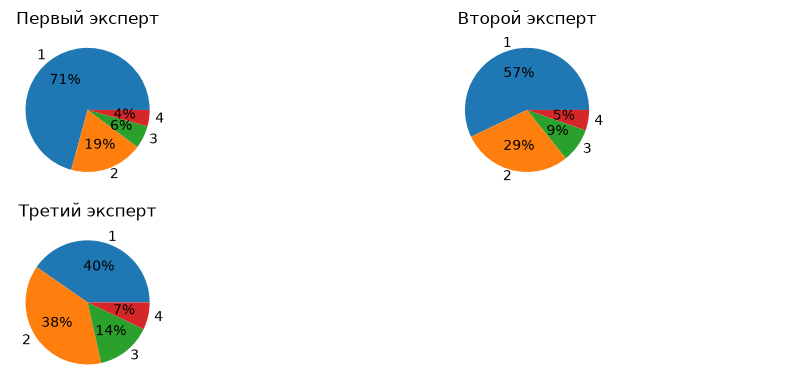

In [131]:
fig, ax = plt.subplots(2, 2, figsize=(10, 4))

expert_dataset['first_expert'].value_counts().plot.pie(ax=ax[0, 0], autopct='%1.f%%')
ax[0, 0].set_title('Первый эксперт')
ax[0, 0].set_ylabel('')

expert_dataset['second_expert'].value_counts().plot.pie(ax=ax[0, 1], autopct='%1.f%%')
ax[0, 1].set_title('Второй эксперт')
ax[0, 1].set_ylabel('')

expert_dataset['third_expert'].value_counts().plot.pie(ax=ax[1, 0], autopct='%1.f%%')
ax[1, 0].set_title('Третий эксперт')
ax[1, 0].set_ylabel('')

ax[1, 1].axis('off')

plt.tight_layout()
plt.show()

По всем трем экспертам можно отметить следующее:
- Оценка 4 - "Полное соответстие" составляет наименьшую часть и в трех случаях не превышает 7%;
- Самую большую долю во всех трех случая составляет оценка с полным не соответстием.

Также между тремя экспертами можно отметить, что у первого доля полного не соответтсвия самая большая, а у третьего она снижается до 40% и почти составляет паритет к оценки 3.

Предлагается сделать промежуточную общую оценку по трем экспертам:

In [132]:
expert_dataset['general'] = expert_dataset[['first_expert', 'second_expert', 'third_expert']].mean(axis = 1)

Нормализуем эту оценку:

In [133]:
expert_dataset['general'] = round((expert_dataset['general'] - 1)/3, 2)

In [134]:
expert_dataset['general'].head()

0    0.11
1    0.11
2    0.22
3    0.11
4    0.00
Name: general, dtype: float64

In [135]:
expert_dataset['general'].describe()

count    5821.000000
mean        0.215166
std         0.268942
min         0.000000
25%         0.000000
50%         0.110000
75%         0.330000
max         1.000000
Name: general, dtype: float64

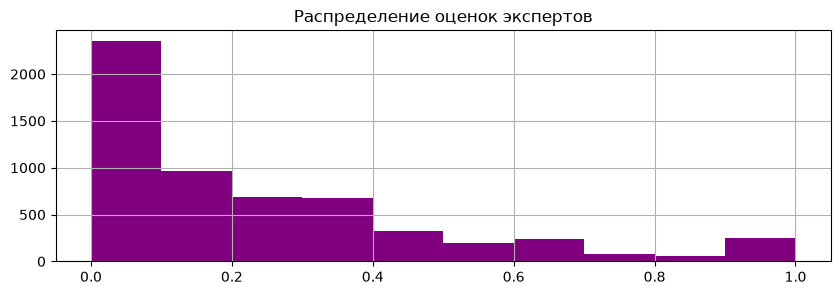

In [136]:
plt.figure(figsize=(10, 3))
plt.title(f'Распределение оценок экспертов')
expert_dataset['general'].hist(color="purple");

### Краудсорсинговые оценки

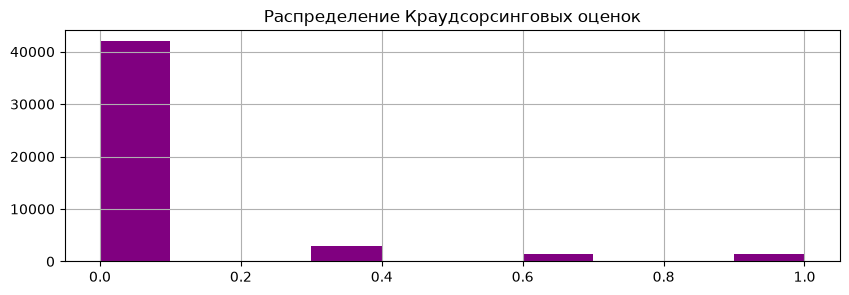

In [137]:
plt.figure(figsize=(10, 3))
plt.title(f'Распределение Краудсорсинговых оценок')
crowd_dataset['confirm_ratio'].hist(color="purple");

По двум группам оценивающим можно сделать вывод, что большинство описаний не соответствует картинкам.

Объеденим датасеты в один:

In [138]:
train_dataset= pd.merge(train_dataset, expert_dataset[['image', 'query_id', 'general']], how='outer', on=['image', 'query_id'])

In [139]:
train_dataset = train_dataset.dropna()

Распределение оценок у экспертов имеет вид с обрывом слева и при этом оно более равномерное чем у оценок с краудфандинга, предлагается в дальнейшем использовать именно их как конечную оценку.

## Лемматизация

In [140]:
train_dataset.head(2)

,image,query_id,query_text,general
1,1056338697_4f7d7ce270.jpg,2718495608_d8533e3ac5.jpg#2,A girl wearing a yellow shirt and sunglasses s...,0.11
2,1056338697_4f7d7ce270.jpg,3181701312_70a379ab6e.jpg#2,A man sleeps under a blanket on a city street .,0.11


In [141]:
train_dataset.query_text = train_dataset.query_text.str.lower()

In [142]:
train_dataset['query_text'] = train_dataset['query_text'].str.replace(r'[^a-zA-Z ]', ' ', regex=True)
train_dataset['query_text'] = train_dataset['query_text'].str.replace(r"what's", 'what is ', regex=True)
train_dataset['query_text'] = train_dataset['query_text'].str.replace(r"\'s", ' ', regex=True)
train_dataset['query_text'] = train_dataset['query_text'].str.replace(r"\'ve", 'have ', regex=True)
train_dataset['query_text'] = train_dataset['query_text'].str.replace(r"can't", 'cannot ', regex=True)
train_dataset['query_text'] = train_dataset['query_text'].str.replace(r"n't", ' not ', regex=True)
train_dataset['query_text'] = train_dataset['query_text'].str.replace(r"i'm", 'i am ', regex=True)
train_dataset['query_text'] = train_dataset['query_text'].str.replace(r"\'re", ' are ', regex=True)
train_dataset['query_text'] = train_dataset['query_text'].str.replace(r"\'d", ' would ', regex=True)
train_dataset['query_text'] = train_dataset['query_text'].str.replace(r"\'ll", ' will ', regex=True)
train_dataset['query_text'] = train_dataset['query_text'].str.replace(r"\W", ' ', regex=True)
train_dataset['query_text'] = train_dataset['query_text'].str.replace(r"\s+", ' ', regex=True)
train_dataset['query_text'] = train_dataset['query_text'].str.replace(r"http\S+", ' ', regex=True)
train_dataset['query_text'] = train_dataset['query_text'].str.replace(r"\S+@\S+", ' ', regex=True)
train_dataset['query_text'] = train_dataset['query_text'].str.replace(r"<.*?>", ' ', regex=True)
train_dataset['query_text'] = train_dataset['query_text'].str.replace(r"[^a-zа-яё ]", ' ', regex=True)

In [143]:
def remove_stopwords(text):
    return " ".join(word for word in text.split() if word not in stop_words)

def lemmatize(text):
    doc = nlp(text)
    lemmas = [
        token.lemma_
        for token in doc
        if not token.is_punct and not token.is_space
    ]
    return " ".join(lemmas)

In [144]:
nlp = spacy.load("en_core_web_sm")
stopwords = set(nltk_stopwords.words('english'))

In [145]:
sentence1 = "Macdonalds Im loving it"
sentence2 = "Are you riding a bycicle? That is so cool"
df_my = pd.DataFrame([sentence1, sentence2], columns = ['text'])
print(df_my)
print()
print(df_my['text'].apply(lemmatize))

                                        text
0                    Macdonalds Im loving it
1  Are you riding a bycicle? That is so cool

0                  Macdonalds I m love it
1    be you rid a bycicle that be so cool
Name: text, dtype: str


In [146]:
train_dataset['query_text'].head(2)

1    a girl wearing a yellow shirt and sunglasses s...
2       a man sleeps under a blanket on a city street 
Name: query_text, dtype: str

In [147]:
train_dataset['lemm_query_text'] = train_dataset['query_text'].progress_apply(lemmatize)

  0%|          | 0/5821 [00:00<?, ?it/s]

In [148]:
train_dataset['lemm_query_text'].head(2)

1    a girl wear a yellow shirt and sunglasse smile
2      a man sleep under a blanket on a city street
Name: lemm_query_text, dtype: str

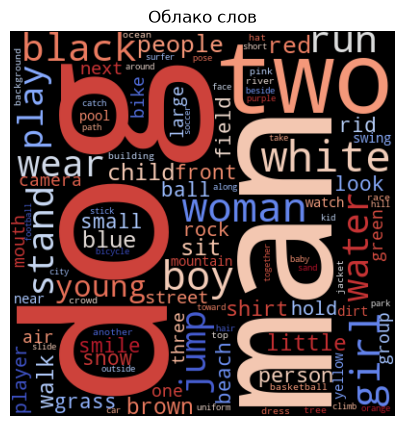

In [149]:
text = ' '.join(train_dataset['lemm_query_text'].astype(str).tolist())
text = ' '.join(word for word in text.split() if word not in stopwords)

back_color = 'black'
wordcloud = WordCloud(width=400, height=400, background_color=back_color, max_words=100,collocations=False,\
                      colormap='coolwarm').generate(text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')

plt.title("Облако слов")

plt.show()

### Промежуточные итоги

На этапе исследовательского анализа данных была проведена агрегация экспертных оценок описаний изображений, а исходная шкала оценивания экспертов была преобразована из диапазона 1–4 в диапазон 0–1.  

В ходе подготовки данных к агрегации было установлено, что первый из трех экспертов оценивал описания наиболее строго: именно он чаще других фиксировал несоответствие изображения и его описания.  

Анализ краудсорсинговых данных также показал значительное количество описаний, не соответствующих содержанию изображений. В большинстве случаев результаты краудсорсингового голосования свидетельствовали о несоответствии текста и изображения.
В качестве итоговой оценки соответствия изображения тексту было решено использовать агрегированную экспертную оценку.  

После формирования общего датафрейма с объединенными оценками были удалены избыточные столбцы, в результате чего был сохранен только столбец с итоговыми оценками.  

Для запросов из тестового датафрейма была выполнена очистка и лемматизация текста. Содержимое запросов было визуализировано с помощью облака слов. Среди наиболее часто встречающихся слов выделены: dog, man, two, white, black, girl.

## Проверка данных

В некоторых странах, где работает ваша компания, действуют ограничения по обработке изображений: поисковым сервисам и сервисам, предоставляющим возможность поиска, запрещено без разрешения родителей или законных представителей предоставлять любую информацию, в том числе, но не исключительно тексты, изображения, видео и аудио, содержащие описание, изображение или запись голоса детей. Ребёнком считается любой человек, не достигший 16 лет.

В вашем сервисе строго следуют законам стран, в которых работают. Поэтому при попытке посмотреть изображения, запрещённые законодательством, вместо картинок показывается дисклеймер:

> This image is unavailable in your country in compliance with local laws
>

Однако у вас в PoC нет возможности воспользоваться данным функционалом. Поэтому все изображения, которые нарушают данный закон, нужно удалить из обучающей выборки.

In [150]:
ban_list  = [
    'baby',
    'infant',
    'newborn',
    'toddler',
    'kid',
    'child',
    'children',
    'boy',
    'girl',
    'young boy',
    'young girl',
    'little boy',
    'little girl',
    'young child',
    'little child',
    'preschooler',
    'preschool child',
    'kindergartener',
    'schoolboy',
    'schoolgirl',
    'school kid',
    'school child',
    'preteen',
    'pre-teen',
    'tween',
    'tweenager',
    'teenage boy',
    'teenage girl',
    'teen boy',
    'teen girl',
    'young teenager',
    'teenager',
    'minor',
    'juvenile'
]

In [151]:
def mark_kids(text):
    text_s = text.lower().split()
    
    for w in text_s:
        if w in ban_list:
            return True
    
    return False

In [152]:
sentence1 = "teenage boy looking at dog"
sentence2 = "young child"
df_my = pd.DataFrame([sentence1, sentence2], columns = ['text'])
print(df_my)
print()
print(df_my['text'].apply(lemmatize))

                         text
0  teenage boy looking at dog
1                 young child

0    teenage boy look at dog
1                young child
Name: text, dtype: str


In [153]:
print(df_my['text'].apply(mark_kids))

0    True
1    True
Name: text, dtype: bool


In [154]:
train_dataset['banned'] = train_dataset['lemm_query_text'].apply(mark_kids)

In [155]:
train_dataset.head(2)

,image,query_id,query_text,general,lemm_query_text,banned
1,1056338697_4f7d7ce270.jpg,2718495608_d8533e3ac5.jpg#2,a girl wearing a yellow shirt and sunglasses s...,0.11,a girl wear a yellow shirt and sunglasse smile,True
2,1056338697_4f7d7ce270.jpg,3181701312_70a379ab6e.jpg#2,a man sleeps under a blanket on a city street,0.11,a man sleep under a blanket on a city street,False


In [156]:
len(train_dataset.loc[train_dataset['banned'] == False, 'image'].unique())

993

In [157]:
len(train_dataset)

5821

Оставим только нужные поля:

In [158]:
train_dataset = train_dataset.loc[train_dataset['banned'] == False, ['image', 'query_id', 'lemm_query_text','general']]

In [159]:
len(train_dataset)

4263

## Векторизация изображений

Перейдём к векторизации изображений.

Самый примитивный способ — прочесть изображение и превратить полученную матрицу в вектор. Такой способ нам не подходит: длина векторов может быть сильно разной, так как размеры изображений разные. Поэтому стоит обратиться к свёрточным сетям: они позволяют "выделить" главные компоненты изображений. Как это сделать? Нужно выбрать какую-либо архитектуру, например ResNet-18, посмотреть на слои и исключить полносвязные слои, которые отвечают за конечное предсказание. При этом можно загрузить модель данной архитектуры, предварительно натренированную на датасете ImageNet.

In [160]:
def load_train(path='data'):
    train_datagen = ImageDataGenerator(
        rescale=1. / 255,
        horizontal_flip=True
    )

    train_datagen_flow = train_datagen.flow_from_dataframe(
        dataframe=train_dataset,
        directory=path + '/train_images',
        x_col='image',
        y_col='score',
        class_mode='input',
        target_size=(150, 150),
        batch_size=32,
        seed=12345
    )

    return train_datagen_flow

Found 4263 validated image filenames.


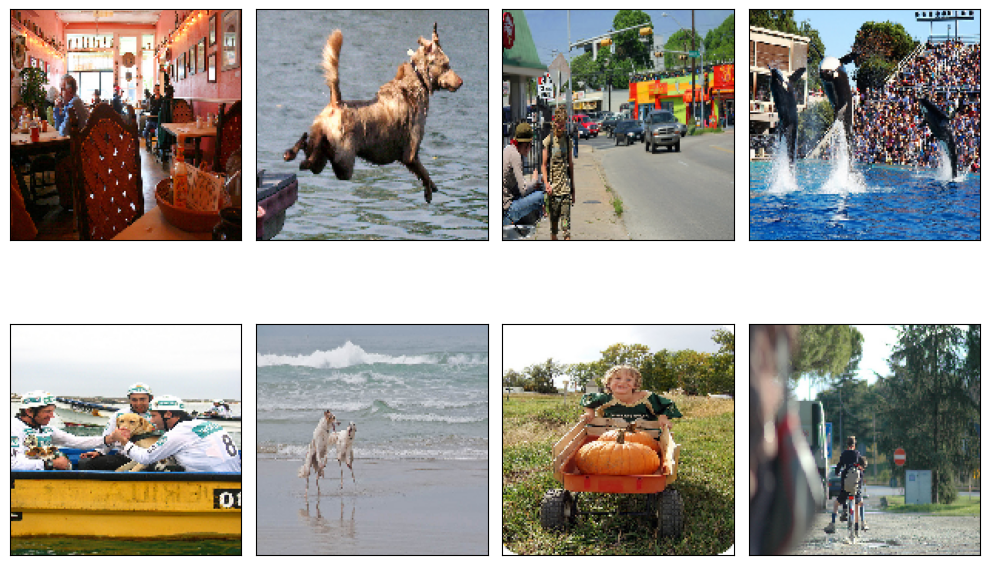

In [161]:
flow_train = load_train()
features, target = next(flow_train)

fig = plt.figure(figsize=(10,10))
for i in range(8):
    fig.add_subplot(3, 4, i+1)
    plt.imshow(features[i])
    plt.xticks([])
    plt.yticks([])
    plt.tight_layout()
plt.show()

Не смотря на нашу фильтрацию, на последнем фото попали дети.

In [162]:
def create_model(input_shape):
    backbone = ResNet50(input_shape=input_shape,
                        weights='imagenet',
                        include_top=False)
    optimizer = Adam(learning_rate=0.0001)
    model = Sequential()
    model.add(backbone)
    model.add(GlobalAveragePooling2D())

    model.compile(optimizer=optimizer,
                  loss='mean_squared_error',
                  metrics=['mae'])
    return model

In [163]:
def image_vector(model, train_data):
    img_vector = model.predict(train_data)
    return img_vector

In [164]:
image_vectors = image_vector(create_model((150, 150, 3)), load_train())

Found 4263 validated image filenames.
134/134 ━━━━━━━━━━━━━━━━━━━━ 54s 395ms/step


In [165]:
image_vectors.shape

(4263, 2048)

## Векторизация текстов

Следующий этап — векторизация текстов. Вы можете поэкспериментировать с несколькими способами векторизации текстов:

- tf-idf
- word2vec
- \*трансформеры (например Bert)

\* — если вы изучали трансформеры в спринте Машинное обучение для текстов.


In [166]:
vectorizer = TfidfVectorizer(lowercase=True,
    max_features=10000)

In [167]:
tfidf_matrix = vectorizer.fit_transform(train_dataset['lemm_query_text'])

In [168]:
print(tfidf_matrix.shape)

(4263, 1020)


In [169]:
tfidf_matrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 36283 stored elements and shape (4263, 1020)>

In [170]:
words = vectorizer.get_feature_names_out()

print(words[:20])

['about' 'above' 'across' 'action' 'actor' 'adult' 'aerial'
 'aerodynamically' 'after' 'against' 'aged' 'ahead' 'air' 'airborne'
 'alert' 'all' 'ally' 'almost' 'alone' 'along']


## Объединение векторов

Подготовьте данные для обучения: объедините векторы изображений и векторы текстов с целевой переменной.

In [171]:
X = hstack([tfidf_matrix, csr_matrix(image_vectors)])
print(X.shape)

(4263, 3068)


In [172]:
y = np.array(train_dataset['general'])

## Обучение модели предсказания соответствия

Для обучения разделите датасет на тренировочную и тестовую выборки. Простое случайное разбиение не подходит: нужно исключить попадание изображения и в обучающую, и в тестовую выборки.
Для того чтобы учесть изображения при разбиении, можно воспользоваться классом [GroupShuffleSplit](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GroupShuffleSplit.html) из библиотеки sklearn.model_selection.

Код ниже разбивает датасет на тренировочную и тестовую выборки в пропорции 7:3 так, что строки с одинаковым значением 'group_column' будут содержаться либо в тестовом, либо в тренировочном датасете.

```
from sklearn.model_selection import GroupShuffleSplit
gss = GroupShuffleSplit(n_splits=1, train_size=.7, random_state=42)
train_indices, test_indices = next(gss.split(X=df.drop(columns=['target']), y=df['target'], groups=df['group_column']))
train_df, test_df = df.loc[train_indices], df.loc[test_indices]

```

Какую модель использовать — выберите самостоятельно. Также вам предстоит выбрать метрику качества либо реализовать свою.

### Подготовка выборок 

#### Тренировочная и тестовая выборки

In [173]:
gss = GroupShuffleSplit(n_splits=1, train_size=.7, random_state=RANDOM_STATE)
train_val_indices, test_indices = next(gss.split(X=X, y=y, groups=train_dataset['image']))

In [174]:
X_train_val = X[train_val_indices]
y_train_val = y[train_val_indices]

X_test = X[test_indices]
y_test = y[test_indices]

groups_train_val = train_dataset['image'].iloc[train_val_indices]

### Валидационная выборка (для нейросети)

In [175]:
gss_val = GroupShuffleSplit(
    n_splits=1,
    train_size=0.8,
    random_state=RANDOM_STATE
)

train_indices, val_indices = next(
    gss_val.split(
        X=X_train_val,
        y=y_train_val,
        groups=groups_train_val
    )
)

X_train = X_train_val[train_indices]
X_val = X_train_val[val_indices]

y_train = y_train_val[train_indices]
y_val = y_train_val[val_indices]

In [176]:
scaler = StandardScaler(with_mean=False)

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Baseline модель линейной регрессии

In [177]:
LR_model = LinearRegression(n_jobs=-1)

In [178]:
cv_mae = cross_val_score(
    LR_model,
    X_train,
    y_train,
    cv=5,
    scoring='neg_mean_absolute_error'
)

In [179]:
LR_score = -cv_mae.mean()
print('Средний MAE:', -cv_mae.mean())

Средний MAE: 1.5465370362313218


### Модель CatBoost

In [180]:
kf = KFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

In [181]:
CBR_model = CatBoostRegressor(learning_rate=0.3, 
                          n_estimators=40,
                          depth=8, 
                          random_state = RANDOM_STATE, 
                          logging_level='Silent')

In [182]:
params_catb = {
    'depth': [5, 6, 7, 8]
}

random_catb = RandomizedSearchCV(
    CBR_model,
    param_distributions=params_catb,
    n_iter=4,
    cv=kf,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1
)

In [183]:
random_catb.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",CatBoostRegre...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'depth': [5, 6, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",4
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``be

In [184]:
CBR_score = -random_catb.best_score_
CBR_score

np.float64(0.2187079789685814)

### Нейросетевая модель (с нормализацией батчей)

In [185]:
print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))

2.21.0
[]


In [186]:
X_train.shape

(2419, 3068)

In [187]:
NN = Sequential()
NN.add(Dense(3068, input_shape=(3068,), activation='relu'))
NN.add(BatchNormalization())
NN.add(Dense(1534, activation='relu'))
NN.add(BatchNormalization())
NN.add(Dense(767, activation='relu'))
NN.add(BatchNormalization())
NN.add(Dense(1, activation='relu'))

optimizer = Adam(learning_rate=0.001)

NN.compile(optimizer=optimizer, loss='mean_squared_error',
            metrics=[tf.keras.metrics.MeanAbsoluteError()])

NN.build()

#NN.summary()

C:\Users\Виктор\Desktop\Шпаргалки\сборный_проект_5\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [188]:
print(X_train.shape)
print(X_test.shape)

(2419, 3068)
(1247, 3068)


In [189]:
early_stop = EarlyStopping(
    monitor='val_mean_absolute_error',
    mode='min',
    patience=15,
    restore_best_weights=True)

history = NN.fit(
            X_train, 
            y_train,
            validation_data=(X_val, y_val),
            batch_size=32, 
            epochs=30,
            callbacks=[early_stop],
            verbose=2, 
            shuffle=True)

Epoch 1/30
76/76 - 9s - 122ms/step - loss: 1.3174 - mean_absolute_error: 0.5446 - val_loss: 0.1398 - val_mean_absolute_error: 0.2397
Epoch 2/30
76/76 - 7s - 96ms/step - loss: 0.1440 - mean_absolute_error: 0.2389 - val_loss: 0.1398 - val_mean_absolute_error: 0.2397
Epoch 3/30
76/76 - 7s - 97ms/step - loss: 0.1288 - mean_absolute_error: 0.2297 - val_loss: 0.1398 - val_mean_absolute_error: 0.2397
Epoch 4/30
76/76 - 7s - 97ms/step - loss: 0.1253 - mean_absolute_error: 0.2273 - val_loss: 0.1398 - val_mean_absolute_error: 0.2397
Epoch 5/30
76/76 - 7s - 96ms/step - loss: 0.1127 - mean_absolute_error: 0.2169 - val_loss: 0.1398 - val_mean_absolute_error: 0.2397
Epoch 6/30
76/76 - 7s - 97ms/step - loss: 0.1120 - mean_absolute_error: 0.2178 - val_loss: 0.1398 - val_mean_absolute_error: 0.2397
Epoch 7/30
76/76 - 7s - 95ms/step - loss: 0.1093 - mean_absolute_error: 0.2117 - val_loss: 0.1398 - val_mean_absolute_error: 0.2397
Epoch 8/30
76/76 - 7s - 96ms/step - loss: 0.1137 - mean_absolute_error: 0.2

In [190]:
NN_score = min(history.history['mean_absolute_error'])
print(NN_score)

0.19323700666427612


### Промежуточные итоги

In [191]:
df_scores = pd.DataFrame({
    'Модель': [
        'Нейросетевая модель',
        'CatBoost регрессор',
        'Линейная регрессия'
    ],
    'Метрика MAE': [
        NN_score,
        CBR_score,
        LR_score
    ]
})

df_scores = df_scores.sort_values('Метрика MAE')
df_scores

,Модель,Метрика MAE
0,Нейросетевая модель,0.193237
1,CatBoost регрессор,0.218708
2,Линейная регрессия,1.546537


По результатам работы на тренировочных данных, самой лучшей моделью по MAE стала нейросетевая модель.  
Ее мы будем использовать на тестовых данных.

## 7. Тестирование модели

Настало время протестировать модель. Для этого получите эмбеддинги для всех тестовых изображений из папки `test_images`, выберите случайные 10 запросов из файла `test_queries.csv` и для каждого запроса выведите наиболее релевантное изображение. Сравните визуально качество поиска.

In [209]:
def load_test(path='data'):

    test_datagen = ImageDataGenerator(
        rescale=1./255,
        horizontal_flip=True)
    
    test_gen_flow = test_datagen.flow_from_dataframe(
        dataframe=test_images,
        directory=path + '/test_images',
        x_col='image',
        y_col=None,
        target_size=(150, 150),
        batch_size=32,
        class_mode='input',
        seed=12345)

    return test_gen_flow

Found 100 validated image filenames.


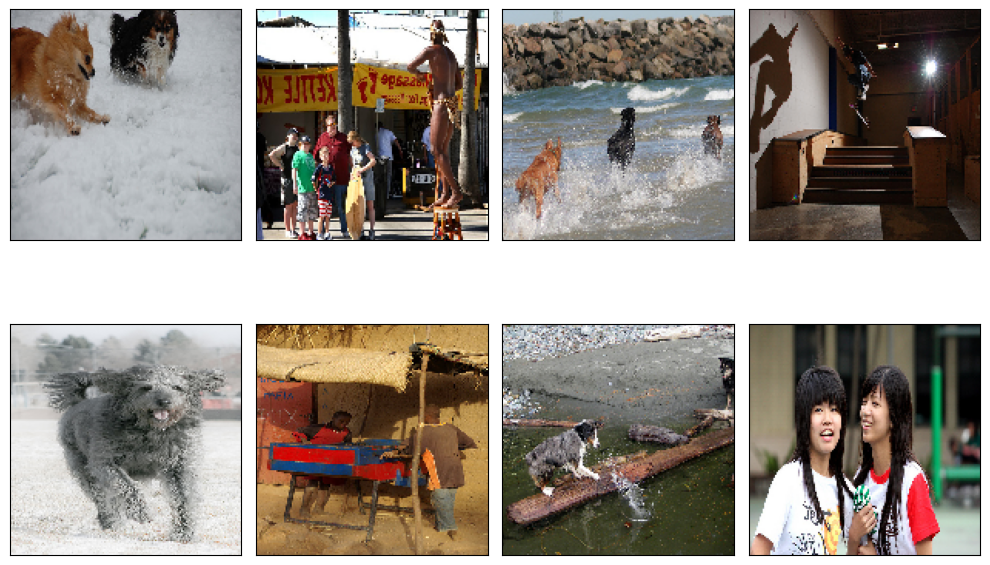

In [210]:
flow_test = load_test()
features, target = next(flow_train)

fig = plt.figure(figsize=(10,10))
for i in range(8):
    fig.add_subplot(3, 4, i+1)
    plt.imshow(features[i])
    plt.xticks([])
    plt.yticks([])
    plt.tight_layout()
plt.show()

In [211]:
test_embeddings = image_vector(create_model((150, 150, 3)), load_test())
test_embeddings.shape

Found 100 validated image filenames.
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 686ms/step


(100, 2048)

In [254]:
queries = queries_dataset.sample(3)

queries['lemm_query_text'] = queries['query_text'].progress_apply(lemmatize)
queries['ban'] = queries['lemm_query_text'].progress_apply(mark_kids)

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

In [255]:
queries.head(2)

,query_id,query_text,image,lemm_query_text,ban
71,2141713971_e25eb12712.jpg#1,"A woman and a younger girl , both wearing blue...",2141713971_e25eb12712.jpg,a woman and a young girl both wear blue jacket...,True
38,1745110280_0cbff5e273.jpg#3,Stretched image of a brown dog with a white pa...,1745110280_0cbff5e273.jpg,stretched image of a brown dog with a white pa...,False


In [256]:
print(tfidf_matrix.shape)
print(test_embeddings.shape)
print(X_train.shape)

(4263, 1020)
(100, 2048)
(2419, 3068)



 This image is unavailable in your country in compliance with local laws. 

In process...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


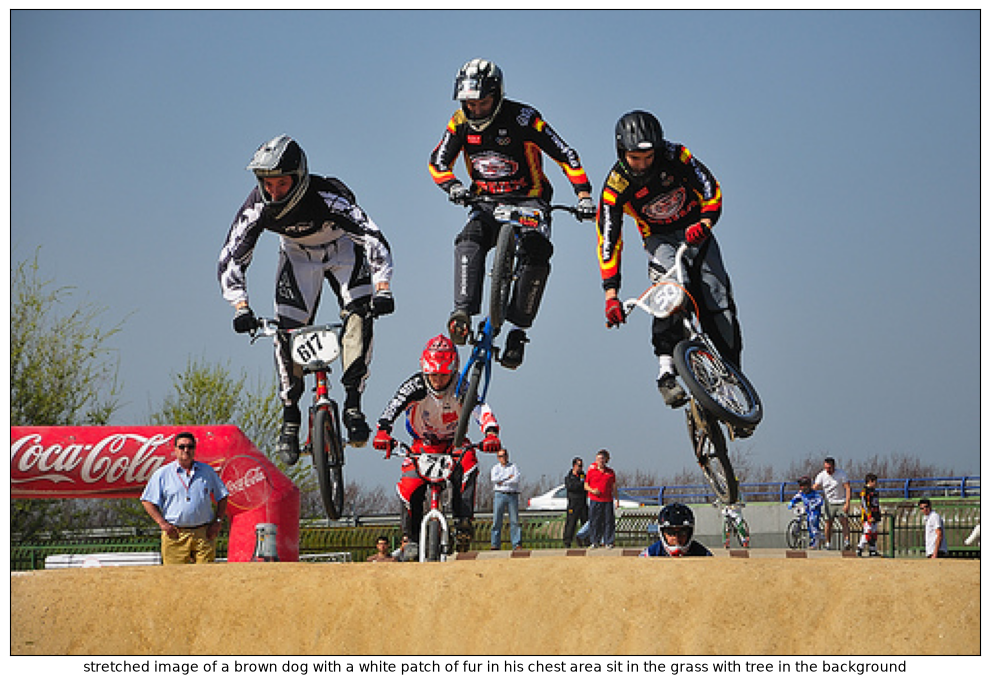


 This image is unavailable in your country in compliance with local laws. 



In [257]:
for index in queries.index:
  if queries.loc[index,'ban'] == True:
    print('\n This image is unavailable in your country in compliance with local laws. \n')
  else:
    print('In process...')

      
    query_tfidf = vectorizer.transform([queries.loc[index, 'lemm_query_text']])
    query_tfidf = query_tfidf.toarray()
    query_tfidf = np.repeat(query_tfidf, test_embeddings.shape[0], axis=0)
      
    X = np.concatenate((query_tfidf, test_embeddings), axis=1)    
    X = scaler.transform(X)

    predictions = NN.predict(X)

    df = pd.concat((test_images, pd.Series(np.reshape(predictions, (predictions.shape[0],)), name='pred')), axis=1) 
    
    top = list(df.sort_values(by='pred', ascending=False)['image'].head(3))
    top_score = list(df.sort_values(by='pred', ascending=False)['pred'].head(3))

    fig = plt.figure(figsize=(10,10))
    image = Image.open(Path('data', 'test_images', top[0]))
    plt.imshow(image)
    plt.xticks([])
    plt.yticks([])
    plt.xlabel(queries.loc[index,'lemm_query_text'])
    plt.tight_layout()
    plt.show()

Наблюдается существенное несоответствие содержания изображений семантике пользовательских запросов. В результатах рекомендаций также присутствуют изображения, подпадающие под установленные ограничения. Вероятной причиной является отсутствие аналогичной фильтрации тестовых данных, применявшейся при подготовке обучающей выборки.

Высокое расхождение между запросами и результатами поиска может быть обусловлено некорректным формированием или объединением текстовых и визуальных признаков, а также недостатками на этапе построения эмбеддингов.


## Вывод

Целью работы являлась разработка модели машинного обучения, способной на основе поискового запроса определять наиболее подходящее по содержанию изображение.

При разработке решения необходимо было учитывать **юридические ограничения**, в частности исключить из анализа и итоговой выдачи изображения с детьми.

Для обучения использовался датасет, содержащий **1000 уникальных изображений**. Каждому изображению соответствовало несколько текстовых описаний, качество соответствия которых содержанию изображения оценивалось как экспертами, так и посредством краудсорсингового сервиса.

Проведенный анализ показал **низкое качество соответствия текстовых описаний содержанию изображений** как по экспертным оценкам, так и по результатам краудсорсинга. В качестве целевой переменной для обучения моделей были выбраны **агрегированные экспертные оценки**, поскольку они были признаны более надежными.

Для соблюдения юридических требований из тренировочной выборки были удалены изображения и текстовые запросы, содержащие упоминания детей. В результате объем данных, доступных для обучения, существенно сократился. При этом проведенная фильтрация не позволила полностью исключить контент, подпадающий под установленные ограничения. Возможными причинами являются **недостаточная полнота фильтрации и ошибки в исходной разметке данных**.

После векторизации текстовых и визуальных признаков были обучены четыре модели:

* линейная регрессия;
* градиентный бустинг;
* нейронная сеть;

В качестве основной метрики использовалась **MAE (Mean Absolute Error)**, поскольку она менее чувствительна к выбросам по сравнению с квадратичной ошибкой.

Лучший результат показала **нейросетевая модель — MAE = 0.18**.

Качество модели дополнительно проверялось на тестовой выборке путем сопоставления **10 случайных поисковых запросов** с изображениями, рекомендованными моделью. Анализ результатов показал **существенное расхождение между семантикой запросов и содержанием рекомендованных изображений**.

Возможными причинами низкого качества выдачи являются:

* недостаточное качество и объем обучающей выборки;
* особенности формирования текстовых и визуальных признаков;
* некорректное объединение эмбеддингов изображения и запроса;
* недостатки используемого подхода к векторизации;
* наличие в тестовой выборке контента, который не был исключен на этапе фильтрации.

Таким образом, **в текущем виде модель не обеспечивает приемлемого качества поиска изображений по текстовому запросу**. Дальнейшее повышение качества, вероятно, потребует формирования более качественной и репрезентативной обучающей выборки, улучшения процедуры фильтрации и совершенствования подхода к формированию и объединению текстовых и визуальных признаков.


## Чек-лист проекта

- [x]  Jupyter Notebook открыт
- [x]  Весь код выполняется без ошибок
- [x]  Ячейки с кодом расположены в порядке исполнения
- [x]  Исследовательский анализ данных выполнен
- [x]  Проверены экспертные оценки и краудсорсинговые оценки
- [x]  Из датасета исключены те объекты, которые выходят за рамки юридических ограничений
- [x]  Изображения векторизованы
- [x]  Текстовые запросы векторизованы
- [x]  Данные корректно разбиты на тренировочную и тестовую выборки
- [x]  Предложена метрика качества работы модели
- [x]  Предложена модель схожести изображений и текстового запроса
- [x]  Модель обучена
- [x]  По итогам обучения модели сделаны выводы
- [x]  Проведено тестирование работы модели
- [x]  По итогам тестирования визуально сравнили качество поиска